In [ ]:
def linear_regression_solution(ws, vector) -> list:
    result = list()
    for i in range(len(vector)):
        w0 = ws[0]
        summa = 0
        for j in range(len(vector[i])):
            summa += ws[j + 1] * vector[i][j]
        summa += w0
        result.append(summa)
    return result


linear_regression_solution([1, 3, 2, -1], [[10, -1, 14], [20, 10, 4]])

[15, 77]

In [ ]:
def round_to_2(x):
    return round(x, 2)


def mean_absolute_difference_solution(real, predicted) -> float:
    summa = 0
    n = len(real)
    for i in range(len(real)):
        summa += abs(real[i] - predicted[i])
    return round_to_2(summa / n)

In [ ]:
def round_to_2(x):
    return round(x, 2)


def split_line(line, sep):
    res = []

    prev_ind = -1
    in_quotes = False

    for i in range(len(line)):
        ch = line[i]

        if ch == '"':
            in_quotes = not in_quotes

        if not in_quotes and ch == sep:
            res.append(line[prev_ind + 1:i].strip('"'))
            prev_ind = i

    if prev_ind < len(line) - 1:
        res.append(line[prev_ind + 1:len(line)].strip('"'))
    elif prev_ind == len(line) - 1:
        res.append('')

    return res


def read_csv_and_calc_mean_solution(lines, sep, column_name) -> float:
    lines = [split_line(i, sep) for i in lines]
    names, lines = lines[0], lines[1:]
    index = names.index(column_name)
    summa = 0
    k = len(lines)
    for i in range(len(lines)):
        summa += int(lines[i][index])
    return round_to_2(summa / k)

In [ ]:
import pandas as pd

df = pd.read_csv("/content/movies_data (2).csv")
df = df[~df["Год производства"].isna()]
df = df[(df["Жанр фильма"] == "Драма") & (df["Страна производства"] == "Франция")]
print(len(df.iloc[:]))


df = pd.read_csv("/content/movies_data (2).csv")
df = df[~df["Год производства"].isna()]
df = df[(df["Страна производства"] == "Россия") & (df["Год производства"] > 2010)]
print(len(df.iloc[:]))


df = pd.read_csv("/content/movies_data (2).csv")
df = df[~df["Год производства"].isna()]
df = df[(df["Страна производства"] == "Россия") | ((df["Год производства"] < 2000) & (df["Жанр фильма"] == "Триллер"))]
print(len(df.iloc[:]))

235
1312
3299


In [ ]:
import pandas as pd

df = pd.read_csv("/content/movies_budget (2).csv", sep=";")
df["доход"] = df["Стоимость билета"] * df["Число зрителей"]
print(df["доход"].mean())

67278893.76


In [ ]:
import pandas as pd

df = pd.read_csv("/content/movies_budget (2).csv", sep=";")
df["доход"] = df["Стоимость билета"] * df["Число зрителей"]
df["Расходы на рекламу"] = df["Бюджет"] / 2
df["прибыль"] = 0.5 * df["доход"] - df["Бюджет"] - df["Расходы на рекламу"]
print(df["прибыль"].max())

In [ ]:
import pandas as pd

df = pd.read_csv("/content/movies_budget (3).csv", sep=";")
df = df.groupby("Жанр фильма").aggregate({"Число зрителей": "sum"}).sort_values("Число зрителей")
df

In [ ]:
import pandas as pd

df = pd.read_csv("/content/movies_budget (3).csv", sep=";")


def transform_countries_info(movies_data):
    countries = ['Россия', 'Германия', 'США', 'Италия', 'Франция']
    new_columns = [[] for i in range(len(countries))]

    for _, row in movies_data.iterrows():
        country_of_origin_united = row['Страна производства']
        countries_of_origin = country_of_origin_united.split('-')

        for i in range(len(countries)):
            country = countries[i]

            if country in countries_of_origin:
                new_columns[i].append('Да')
            else:
                new_columns[i].append('Нет')

    for i in range(len(countries)):
        movies_data[countries[i]] = new_columns[i]


transform_countries_info(df)
df

df = df[df["Россия"] == "Да"]
df = df.groupby("Жанр фильма").aggregate({"Число зрителей": "count"}).sort_values("Число зрителей")
df

In [ ]:
import pandas as pd
import seaborn as sns

df = pd.read_csv("/content/many_factors_data (1).csv", sep=",")
sns.pairplot(df)

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np

df = pd.read_csv("/content/uniform_and_not_data (1).csv", sep=",")
sns.histplot(df["E"])

In [ ]:
def count_numbers_solution(list_of_data):
    res = {}
    for i in list_of_data:
      if i in res.keys():
        res[i] += 1
      else:
        res[i] = 1

    return res

Все тесты прошли успешно!


In [ ]:
def new_columns_solution(column):
    categories = column.unique()
    column = column.values
    length = len(column)

    result = {}

    for i in column:
        result[i] = [0 for i in range(length)]

    for i in range(length):
        categoria = column[i]
        result[categoria][i] = 1

    return result

Все тесты прошли успешно!


In [ ]:
def new_columns_solution(column):
    res = {}
    for i in column.unique():
        tmp = []
        for j in range(len(column)):
            if column[j] == i:
                tmp.append(1)
            else:
                tmp.append(0)
        res[i] = tmp
    return res


def categorical_to_binary_solution(data, columns):
    print(data)
    for i in columns:
        container = new_columns_solution(data[i])
        for j in container.keys():
            data[j] = container[j]
    print(data)
    return data

In [ ]:
def round_to_2(x):
    return round(x, 2)

In [ ]:
def target_coding_solution(data, factor_column, target_column):
    encoding_dict = {}
    encoding_table = data.groupby(factor_column)[target_column].mean()
    for value in data[factor_column].unique():
        encoding_dict[value] = round_to_2(encoding_table[value])
    data['encoded'] = data[factor_column].map(encoding_dict)

In [ ]:
import pandas as pd


def standard_deviation_solution(column):
    medium = sum(column) / len(column)
    result = 0
    for i in column:
        result += (i - medium) ** 2
    result /= len(column)
    return round(result ** (1/2), 2)


def standartize_column_solution(column):
    x = sum(column) / len(column)
    s = standard_deviation_solution(column)
    result = []
    if s == 0:
        result = [0.0 for i in column]
        return pd.Series(result)
    for i in column:
        tmp = (i - x) / s
        result.append(float(round(tmp, 2)))
    return pd.Series(result)

1.49
[-1.12, -0.45, -1.12, 0.22, 0.89, 1.57]
0.0
Все тесты прошли успешно!


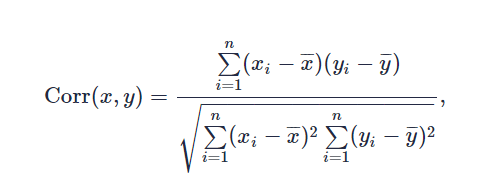

In [ ]:
def correlation_solution(x: list, y: list) -> float:
    x_mean = sum(x) / len(x)
    y_mean = sum(y) / len(y)

    n = len(x)

    summa1 = 0
    summa2 = 0
    summa3 = 0

    for i in range(n):
        summa1 += (x[i] - x_mean) * (y[i] - y_mean)
        summa2 += (x[i] - x_mean) ** 2
        summa3 += (y[i] - y_mean) ** 2

    correlation = summa1 / ((summa2 * summa3) ** (1/2))
    return round(correlation, 2)

In [ ]:
import pandas as pd


def correlation_one_line_solution(x, y):
    return round(((x - x.mean()) * (y - y.mean())).sum() / ((((x - x.mean()) ** 2).sum() * (y - y.mean()) ** 2).sum() ** (1/2)), 2)

0.29
Все тесты прошли успешно!


In [ ]:
from math import exp

def round_to_2(x):
    return round(x, 2)

def sign(x):
    if x > 0:
        return 1

    return -1

def sigmoid(x):
    return round_to_2(1 / (1 + exp(-x)))

def perceptron_classify_solution(ws, xs, f=sign):
    w = ws[:-1]
    b = ws[-1]

    print(w, b)

    result = []
    for i in range(len(xs)):
        tmp = 0
        for j in range(len(xs[i])):
            tmp += w[i] * xs[i][j]
        tmp += b
        result.append(round(f(tmp), 2))
    return result


def perceptron_classify_solution(ws, xs, f=sign):
    return [round_to_2(f(sum(w * x[i] for i, w in enumerate(ws[:-1])) + ws[-1])) for x in xs]



Все тесты прошли успешно!


In [ ]:
from math import exp

def round_to_2(x):
    return round(x, 2)

def sign(x):
    if x > 0:
        return 1

    return -1

def sigmoid(x):
    return round_to_2(1 / (1 + exp(-x)))

def perceptron_classify_solution(ws, xs, f=sign):
    w = ws[:-1]
    b = ws[-1]

    print(w, b)

    result = []
    for i in range(len(xs)):
        tmp = 0
        for j in range(len(xs[i])):
            tmp += w[i] * xs[i][j]
        tmp += b
        result.append(round(f(tmp), 2))
    return result

In [ ]:
def perceptron_classify_solution(ws, xs, f=sign):
    return [round_to_2(f(sum(w * x[i] for i, w in enumerate(ws[:-1])) + ws[-1])) for x in xs]


def learning(w, lambd, x, y, y_predict):
    for i in range(len(w[:-1])):
        w[i] = w[i] + lambd * (y - y_predict) * x[i]
    w[-1] = w[-1] + lambd * (y - y_predict)
    return w


def perceptron_train_solution(xs, ys, learning_rate=1, k=100):
    count = 10 ** 3
    w = [0 for i in range(len(xs[0]))] + [0]
    metric = 10e10

    for i in range(count):

        if count > k and metric <= 0:
            break
        summa = []

        for j in range(len(xs)):

            x = xs[j]
            y = ys[j]
            y_predict = perceptron_classify_solution(w, [x])[0]
            summa += [y_predict]

            if y != y_predict:
                w = learning(w, learning_rate, x, y, y_predict)

        for j in range(len(ys)):
            metric += abs(ys[j] - summa[j])
        metric = metric / (2 * len(ys))

    return w

Все тесты прошли успешно!


In [ ]:
from math import exp

def round_to_2(x):
    return round(x, 2)

def sign(x):
    if x > 0:
        return 1

    return -1

def sigmoid(x):
    return round_to_2(1 / (1 + exp(-x)))

def relu(x):
    if x > 0:
        return x

    return 0

def perceptron_classify_solution(ws, xs, f=sign):
    return [round_to_2(f(sum(w * x[i] for i, w in enumerate(ws[:-1])) + ws[-1])) for x in xs]


def multilayer_perceptron_solution(wss, fs, x):

    for i in range(len(wss)):
        w_s = wss[i]
        tmp = []
        for j in range(len(w_s)):
            tmp.append(perceptron_classify_solution(w_s[j], [x], f=fs[i])[0])
        x = tmp
    return x[0]

Все тесты прошли успешно!


In [ ]:
def dichotomous_search_solution(f, a, b, eps):
    while b - a > 2 * eps:
        medium = (a + b) / 2
        a_e, b_e = (a + b - eps) / 2, (a + b + eps) / 2

        if f(a_e) > f(b_e):
            a = a_e

        if f(a_e) <= f(b_e):
            b = b_e
    return round((a + b) / 2, 2)


f = lambda x: x ** 2
a = -2
b = 2
eps = 0.01
dichotomous_search_solution(f, a, b, eps)

-0.0

In [ ]:
def add(array1, array2):
    result = []
    for i in range(len(array1)):
        result.append(round(array1[i] + array2[i], 2))
    return result


def multiply(const, array):
    for i in range(len(array)):
        array[i] *= const
        array[i] = round(array[i], 2)
    return array


def gradient_descent_solution(grad_f, x_0, alpha, eps):
    xt = add(x_0, multiply(alpha, grad_f(x_0)))
    while x_0 is None or dist_v(xt - x_0) > eps:
        x_0 = xt
        xt = add(x_0, multiply(alpha, grad_f(x_0)))
    return xt

In [ ]:
def string_to_words_solution(string):
    words = []
    s = ""
    for i in range(len(string)):
        if string[i] == " ":
            words.append(s)
            s = ""
        else:
            s += string[i]
    words.append(s)
    return words


def count_word_solution(s, word):
    s = string_to_words_solution(s)
    count = 0
    for i in s:
        if i == word:
            count += 1
    return count


string_to_words_solution("mama papa ")

['mama', 'papa', '']

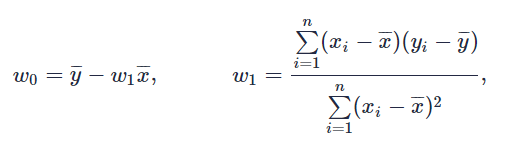

In [ ]:
import pandas as pd


def two_parameters_linear_regression_solution(data, x_name, y_name):

    x = data[x_name].values
    y = data[y_name].values
    w1 = ((x - x.mean()) * (y - y.mean())).sum() / ((x - x.mean()) ** 2).sum()
    w0 = y.mean() - w1 * x.mean()

    return round(w0, 2), round(w1, 2)


data = pd.DataFrame(data=[[1, 3], [2, 2], [4, 4], [5, -1]], columns=['x', 'y'])
two_parameters_linear_regression_solution(data, 'x', 'y')

(3.8, -0.6)

In [ ]:
def matrix_multiplication_solution(matrix_a, matrix_b):
    if len(matrix_a[0]) != len(matrix_b):
        return -1
    result = []

    for i in range(len(matrix_a)):
        row = []
        for j in range(len(matrix_b[0])):
            cell = 0
            for k in range(len(matrix_b)):
                cell += matrix_a[i][k] * matrix_b[k][j]
            row.append(round_to_2(cell))
        result.append(row)
    return result

In [ ]:
def transpose_matrix_solution(matrix):
    n, m = len(matrix), len(matrix[0])
    result = [[0 for i in range(n)] for i in range(m)]

    for i in range(n):
        for j in range(m):
            result[j][i] = matrix[i][j]

    return result

In [ ]:
def linear_regression_predict_solution(w, data, x_names):
    X = data[x_names].to_numpy()  # получаем массив данных X в нормальном виде
    X = np.hstack((np.ones((X.shape[0], 1)), X)) # добавляем Xb
    y_pred = np.dot(X, w) # перемножаем матрицы
    y_pred = np.round(y_pred, 2)
    return y_pred

In [ ]:
def linear_regression_solve_solution(data, x_names, y_name):
    # W = (X^T * X) ^ -1 * X^T * y

    X = data[x_names].to_numpy()
    Y = data[y_name].to_numpy()
    X = np.hstack((np.ones((X.shape[0], 1)), X))
    w = np.linalg.inv(X.T @ X) @ X.T @ Y
    w = np.round(w, 2)
    return w

In [ ]:
import numpy as np
import pandas as pd

def linear_regression_solve_solution(data, x_names, y_name):
    # W = (X^T * X) ^ -1 * X^T * y

    X = data[x_names].to_numpy()
    Y = data[y_name].to_numpy()
    X = np.hstack((np.ones((X.shape[0], 1)), X))
    w = np.linalg.inv(X.T @ X) @ X.T @ Y
    w = np.round(w, 2)
    return w


x = np.array([[1, 1, -1], [1, -1, 1], [1, 1, 1]])
y = np.array([1, -2, 2])

delta = np.array([[0.5, -0.25, -0.25], [-0.25, 0.5, 0.25], [-0.25, 0.25, 0.5]])


w = delta @ x.T @ y
print(w)

[-0.5  2.   0.5]


In [ ]:
n = int(input())
a = list(map(int, input().split()))

flag = True

h1 = a[0]
maximum = 0
for i in range(1, n - 1, 1):
    h2 = a[i]
    if (h1 - h2) >= 0:
        if maximum < (h1 - h2):
            maximum = h1 - h2
        h1 = a[i]
    else:
        print(-1)
        flag = False
        break

if flag:
    if maximum < a[-2] - a[-1]:
        maximum  = a[-2] - a[-1]
    print(maximum)

5
10 8 6 4 1
[10, 8, 6, 4, 1]
10 8
3


In [ ]:
def k_fold_solution(model, data_x, data_y, k, random_gen):
    data_xy = list(zip(data_x, data_y))
    random_gen.shuffle(data_xy)

    data_x_shuffled, data_y_shuffled = zip(*data_xy)

    data_x_split_k = split_into_k(data_x_shuffled, k)
    data_y_split_k = split_into_y(data_y_shuffled, k)

    scores = []

    for i in range(k):
        x_train = []
        y_train = []

        x_test = data_x_split_k[i]
        y_test = data_y_split_k[i]

        for j in range(k):
            if j != i:
                x_train.extend(data_x_split_k[j])
                y_train.extend(data_y_split_k[j])

        x_train = list(x_train)
        y_train = list(y_train)

        model.fit(x_train, y_train)
        score = score_model(model, x_test, y_test)
        scores.append(score)

    score = sum(scores) / k
    return round(score, 3)

Модуль разницы: 0.004
Разброс: 1.205


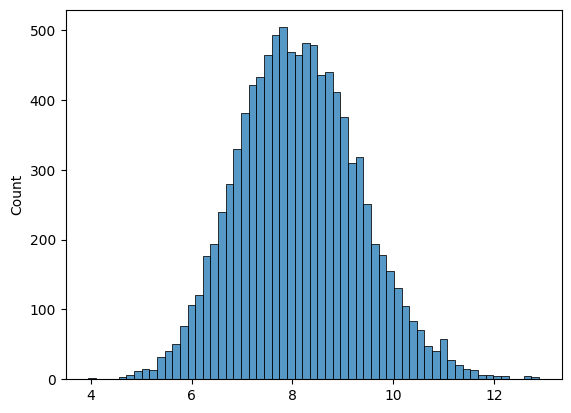

In [ ]:
import numpy as np
import random
import seaborn as sns
import pandas as pd

random.seed(0)

df = pd.read_csv("/content/error_modelling (2).csv")
accuracy_scores = []

for i in range(10000):
    random_df = random.sample(list(df.index), 100)
    accuracy_score = np.mean(np.abs(df['y'].values[random_df] - df["y_pred"].values[random_df]))
    accuracy_scores.append(accuracy_score)

sns.histplot(accuracy_scores)
one_accuracy_sum = np.mean(np.abs(df["y"].values - df["y_pred"].values))
one_mean_accuracy = np.mean(accuracy_scores)

one_accuracy_result = np.abs(one_accuracy_sum - one_mean_accuracy)
two_accuracy_result = np.sqrt(np.mean((accuracy_scores - np.mean(accuracy_scores)) ** 2))

print(f"Модуль разницы: {round(one_accuracy_result, 3)}")
print(f"Разброс: {round(two_accuracy_result, 3)}")

In [ ]:
from math import floor

def round_to_3(x):
    return round(x, 3)

def cut_on_edges(l, fraction_to_cut):
    to_cut = floor(len(l) * fraction_to_cut)
    return l[to_cut:len(l) - to_cut]

def bootstrap_confidence_interval_solution(y, y_pred, fraction_to_cut, random_gen):
    n = len(y)
    accuracy_scores = []

    for i in range(10000):
        bootstrap_sample = random_gen.choices(list(zip(y, y_pred)), k=n)
        bootstrap_y = [j[0] for j in bootstrap_sample]
        bootstrap_y_pred = [j[1] for j in bootstrap_sample]
        accuracy = sum(abs(y_i - y_pred_i) for y_i, y_pred_i in zip(bootstrap_y, bootstrap_y_pred)) / n
        accuracy_scores.append(accuracy)

    accuracy_scores = cut_on_edges(accuracy_scores, fraction_to_cut)
    return round_to_3(min(accuracy_scores)), round_to_3(max(accuracy_scores))